# Load Libraries

In [1]:
options(future.globals.maxSize = 1000000 * 1024^2)
set.seed(12345)
setwd('path')
# ## We load the required packages
library(dplyr)
library(pheatmap)
library(variancePartition)
library(RColorBrewer)
save_plot <-  FALSE


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: limma

Loading required package: BiocParallel


Attaching package: ‘variancePartition’


The following object is masked from ‘package:limma’:

    topTable




# Read Metadata

In [2]:
metadata_new <- readr::read_tsv('2024_11_metadata_new.tsv',col_names = T)

Rows: 30 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (9): donor, sex, race, CL, BL, dx, pathology, mRS_3class, mRS_binned
dbl (11): fastq, mRS, age, PEV, PHV, NIHSS, ICH_Score, TSH, DfCtB, Suspected...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Canonical Correlation

In [3]:
formula <-  paste0(" ~ mRS_binned +
    mRS + 
    mRS_3class +
    TSH + 
    age +
    dx +  
    PHV +
    PEV + 
    sex + 
    race + 
    BL + 
    CL + 
    ICH_Score+
    DfCtB +
    NIHSS +
    Suspected.Etiology..CAA +
    Suspected.Etiology..HTN " ) # pathology+
var_part_cor<- variancePartition::canCorPairs(formula,data =metadata_new)
colnames(var_part_cor)[colnames(var_part_cor) == 'Suspected.Etiology..CAA'] <- 'Susp.Etiol.CAA'
colnames(var_part_cor)[colnames(var_part_cor) == 'Suspected.Etiology..HTN'] <- 'Susp.Etiol.HTN'
rownames(var_part_cor)[rownames(var_part_cor) == 'Suspected.Etiology..CAA'] <- 'Susp.Etiol.CAA'
rownames(var_part_cor)[rownames(var_part_cor) == 'Suspected.Etiology..HTN'] <- 'Susp.Etiol.HTN'

cca_df <- as.data.frame(var_part_cor)
cca_df$RowNames <- rownames(cca_df)

Warning message in variancePartition::canCorPairs(formula, data = metadata_new):
“Regression model may be problematic.
High colinearity between variables:
  BL and CL”


# Plot heatmap

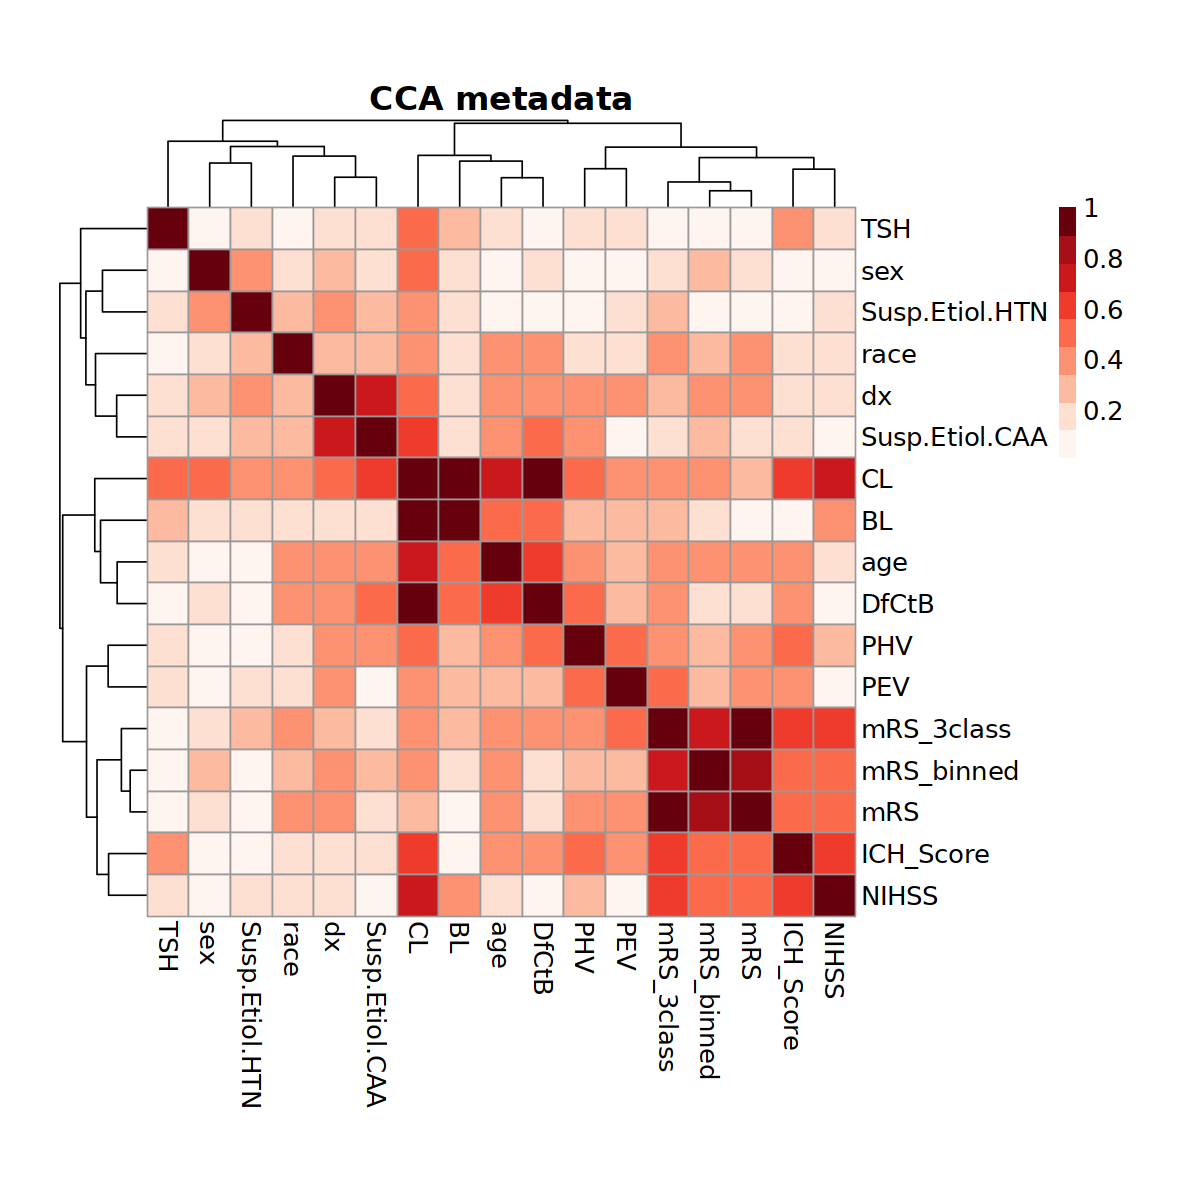

In [4]:

if(save_plot){
    options(repr.plot.width=10, repr.plot.height=10)
    dev.off()
    pheatmap::pheatmap(var_part_cor,main="CCA metadata",cexRow = 0.4, cexCol = 1,
                   cellwidth = 25, 
                   cellheight = 25,fontsize = 15,color=brewer.pal(9, "Reds"),
                   filename="Figure1B_CCA.pdf")
}else{
    options(repr.plot.width=10, repr.plot.height=10)
    pheatmap::pheatmap(var_part_cor,main="CCA metadata",cexRow = 0.4, cexCol = 1,
                   cellwidth = 25, 
                   cellheight = 25,fontsize = 15,color=brewer.pal(9, "Reds"))
}


# Sesssion Info

In [5]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 9.4 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] RColorBrewer_1.1-3       variancePartition_1.31.9 BiocParallel_1.34.2     
[4] limma_3.56.2             ggplot2_3.5.0            pheatmap_1.0.12         
[7] dplyr_1.1.2             

loaded v